In [1]:
import sys
sys.path.append('../../src')
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np 
from TRIOMA.tools.component_tools import Component
from TRIOMA.tools.component_tools import Fluid
from TRIOMA.tools.component_tools import Membrane
import TRIOMA.tools.materials as materials
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from TRIOMA.tools.component_tools import BreedingBlanket
import mph 
from TRIOMA.tools.component_tools import Geometry
inv_v=[]
inv_v_comsol=[]
scatter_mat = np.empty((0, 9))

RESULTS_DIR = 'Results_MS'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [2]:
from scipy.optimize import brentq

# ---- Fixed physical/geometric parameters (held constant in this screening case) ----
T = 800
K_H = 1E-1
K_S = 1E-2
d_hyd = 1E-2
L = 8
thick = 2E-3
U0 = 1.5
mat = materials.Flibe(T)
c0 = 1E-3
p_in = c0 / K_H
log_ro_ri = np.log((d_hyd + 2 * thick) / d_hyd)
tau_vec = np.logspace(-2, np.log10(1), 3)
xi_vec = np.logspace(-2, 1, 4)
p_out_vec = np.linspace(0, p_in / 2, 4)
# tau_vec = np.array([2])
# xi_vec = np.array([10])
# p_out_vec = np.array([0])

def _kt_from_Dflibe(D_flibe):
    """Mass transfer coefficient resulting from a given fluid tritium diffusivity."""
    fl = Fluid(T=T, Solubility=K_H, MS=True, D=D_flibe, d_Hyd=d_hyd,
               mu=mat.mu, rho=mat.rho, U0=U0, k=mat.k, cp=mat.cp)
    fl.get_kt()
    return fl.k_t

def _tau_from_Dflibe(D_flibe):
    return 4 * _kt_from_Dflibe(D_flibe) * L / (U0 * d_hyd)

def _xi_from_D(D_membrane, k_t):
    phi = D_membrane * K_S
    alpha = (1.0 / K_H) * (phi / (k_t * d_hyd * log_ro_ri)) ** 2
    return alpha / c0

def _solve_for_target(func, target, log_lo=-20, log_hi=0):
    """Root-finds x (searched in log10-space, robust across many decades) s.t. func(x) == target."""
    root_log = brentq(lambda lx: np.log(func(10 ** lx) / target), log_lo, log_hi,
                       xtol=1e-14, rtol=1e-14)
    return 10 ** root_log

# Fluid tritium diffusivity (D_flibe) needed to hit each tau extreme (tau depends only on D_flibe)
D_flibe_vec = np.array([_solve_for_target(_tau_from_Dflibe, tau) for tau in tau_vec])
for tau_target, D_flibe in zip(tau_vec, D_flibe_vec):
    print("tau target=", tau_target, "-> D_flibe=", D_flibe, "check tau=", _tau_from_Dflibe(D_flibe))

client = mph.start()
model = client.load('PAV_MS.mph')
model.mesh()

tau target= 0.01 -> D_flibe= 8.205010842584885e-11 check tau= 0.01
tau target= 0.1 -> D_flibe= 2.774157710731763e-09 check tau= 0.09999999999999999
tau target= 1.0 -> D_flibe= 9.379574447445824e-08 check tau= 1.0000000000000013


In [3]:
scatter_mat = np.empty((0, 9))
count=0
n_total = len(p_out_vec) * len(tau_vec) * len(xi_vec)
for p_out in p_out_vec:
    for tau_target, D_flibe in zip(tau_vec, D_flibe_vec):
        k_t_target = _kt_from_Dflibe(D_flibe)
        for xi_target in xi_vec:
                D = _solve_for_target(lambda d: _xi_from_D(d, k_t_target), xi_target, log_lo=-20, log_hi=2)
                count+=1
                print("Iteration",str(count) ,"of",n_total, "| target tau=",tau_target,"xi=",xi_target,"p_ext=",p_out)
                eff_coms_v=np.array([])
                eff_py=np.array([])

                compute_comsol=True
                T_hot_prim=900
                T_cold_prim=800
                Q=1E9
                k_d=1E6
                k_r=1E6
                flibe=Fluid(T=T, Solubility=K_H, MS=True,D=D_flibe, d_Hyd=d_hyd ,mu=mat.mu,rho=mat.rho,U0=U0,k=mat.k,cp=mat.cp)
                flibe.k_t = k_t_target

                Steel = Membrane( T=T,
                                D=D,
                        thick=thick,
                        K_S=K_S,
                        k_d=k_d,
                        k_r=k_r,k=21)
                geom_pav=Geometry(L=L, D=d_hyd,thick=thick , n_pipes=1)
                PAV = Component(c_in=c0,  fluid=flibe, membrane=Steel,geometry=geom_pav, p_ext=p_out)
                inv=PAV.get_solid_inventory()
                PAV.use_analytical_efficiency()
                var_vec=[T,c0,d_hyd,L,D,thick,K_S,K_H,D_flibe,U0,p_out**0.5*PAV.membrane.K_S]
                var_vec_str=['T','c0','d_hyd','L','D_St','thick','K_S','K_H','D_flibe','U0','cext']
                print("")
                if compute_comsol:
                        for i,var in enumerate(var_vec):
                                model.parameter(var_vec_str[i], str(var))
        
                        a=model.parameters()
                        print("D=",D,"D_flibe=",D_flibe,"K_S=",K_S,"K_H=",K_H,"p_out=",p_out)
                        # model.save()
                        # print("Saved")
                        model.solve()
                        # Evaluate the results
                        inv_coms_vec = model.evaluate(['r', 'z', 'inv'], 'Study 1//Solution 1')
                        inv_coms_f_vec=model.evaluate(['r', 'z', 'inv_fluid'], 'Study 1//Solution 1')
                        eff_coms_vec = model.evaluate(['r', 'z', 'eff'], 'Study 1//Solution 1')
                        # Remove NaN values from the 'inv' component
                        inv_values = inv_coms_vec[-1]  # Assuming 'inv' is the last component
                        inv_values = inv_values[~np.isnan(inv_values)]
                        inv_coms_f=inv_coms_f_vec[-1]
                        inv_coms_values_f=inv_coms_f[~np.isnan(inv_coms_f)]
                        eff_coms_values = eff_coms_vec[-1]
                        eff_coms_values = eff_coms_values[~np.isnan(eff_coms_values)]
                        # Calculate the average of the cleaned 'inv' values
                                
                        inv_coms_s = np.average(inv_values)
                        inv_coms_f=np.average(inv_coms_values_f)
                        eff_coms_avg = np.average(eff_coms_values)
                                
                else: 
                        eff_coms_avg=4.22E-6
                        # Append the average to the eff_coms_v array
                if compute_comsol:
                        k_t_coms=model.evaluate(['r', 'z', 'k_t'], 'Study 1//Solution 1')
                        k_t_values=k_t_coms[-1]
                        k_t_values=k_t_values[~np.isnan(k_t_values)]
                        k_t_avg=np.average(k_t_values)
                        print("Trioma k_t=",PAV.fluid.k_t,"Comsol k_t=",k_t_avg)
                        PAV.fluid.k_t=abs(k_t_avg)
                                
                        PAV.use_analytical_efficiency()
                        PAV.get_solid_inventory()
                        inv_s=PAV.membrane.inv
                        PAV.get_fluid_inventory()
                        inv_f=PAV.fluid.inv
                        eff=PAV.eff
                        err_inv_s=abs(inv_s-inv_coms_s)/min(inv_s,inv_coms_s)
                        err_inv_f=abs(inv_f-inv_coms_f)/min(inv_f,inv_coms_f)
                        err_eff=abs(eff-eff_coms_avg)/min(eff,eff_coms_avg)
                        print("PAV solid inv", (PAV.membrane.inv), "Coms=", inv_coms_s, "%", "diff=", PAV.membrane.inv - inv_coms_s, "%", "rel_diff=", err_inv_s*100, "%")
                        print("PAV fluid inv", (PAV.fluid.inv), "Coms=", inv_coms_f, "%", "diff=", PAV.fluid.inv - inv_coms_f, "%", "rel_diff=", err_inv_f*100, "%")
                        print("PAV eff", (PAV.eff), "Coms=", eff_coms_avg, "%", "diff=", PAV.eff - eff_coms_avg, "%", "rel_diff=", err_eff*100, "%")
                        xi=PAV.xi
                        tau=PAV.tau
                        new_row=np.array([xi,tau,p_out,inv_s,err_inv_s,inv_f,err_inv_f,eff,err_eff])
                        scatter_mat = np.vstack((scatter_mat, new_row))  # Append the new row
                inv_v.append(PAV.membrane.inv)
                inv_v_comsol.append(eff_coms_avg)
                PAV.get_solid_inventory(flag_an=True)

Iteration 1 of 48 | target tau= 0.01 xi= 0.01 p_ext= 0.0

D= 1.5772136091619409e-09 D_flibe= 8.205010842584885e-11 K_S= 0.01 K_H= 0.1 p_out= 0.0
Trioma k_t= 4.6875e-06 Comsol k_t= 1.637365318463359e-06
PAV solid inv 2.323292205233134e-07 Coms= 2.3131216496094987e-07 % diff= 1.0170555623635465e-09 % rel_diff= 0.4396896127513423 %
PAV fluid inv 1.256092366941814e-06 Coms= 1.2523886634580931e-06 % diff= 3.703703483720875e-09 % rel_diff= 0.2957311569312849 %
PAV eff 0.0008668366893941348 Coms= 0.0008624433236837877 % diff= 4.393365710347093e-06 % rel_diff= 0.5094092086633054 %
Iteration 2 of 48 | target tau= 0.01 xi= 0.1 p_ext= 0.0

D= 4.987587361566347e-09 D_flibe= 8.205010842584885e-11 K_S= 0.01 K_H= 0.1 p_out= 0.0
Trioma k_t= 4.6875e-06 Comsol k_t= 1.6137144369493045e-06
PAV solid inv 1.7171518808440646e-07 Coms= 1.7032535899695586e-07 % diff= 1.389829087450596e-09 % rel_diff= 0.8159848278819338 %
PAV fluid inv 1.2553637751525814e-06 Coms= 1.2467114326052938e-06 % diff= 8.65234254728761

In [4]:
# # save the scatter_mat in a txt
scatter_mat_file_path = os.path.join(RESULTS_DIR, 'scatter_mat_ms.txt')
np.savetxt(scatter_mat_file_path, scatter_mat, delimiter=',', header='xi,tau,p_out,inv_s,err_inv_s,inv_f,err_inv_f,eff,err_eff', comments='')

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_12440\2937995460.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


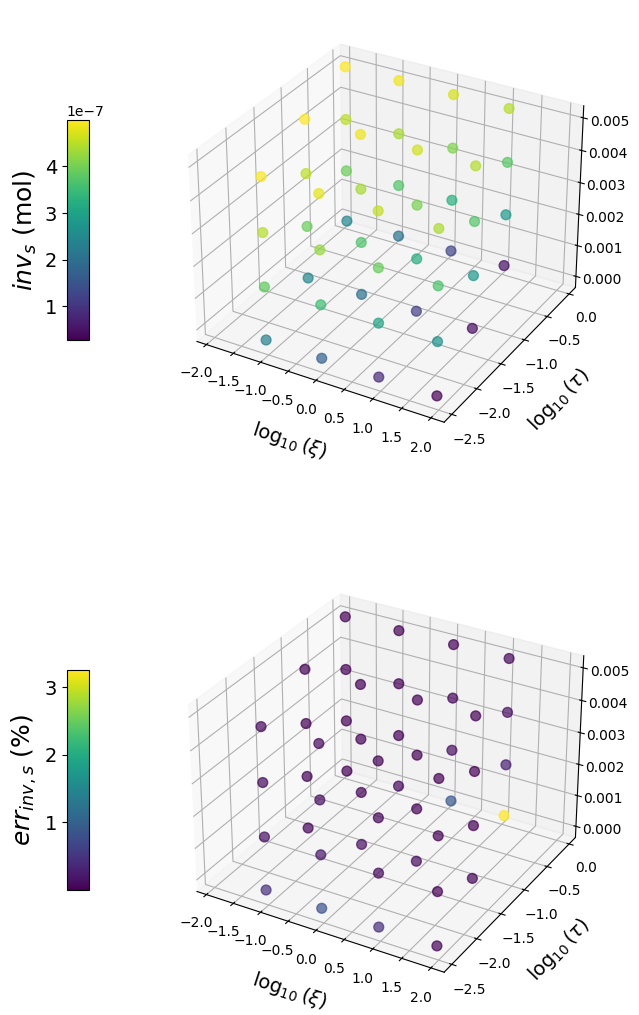

In [5]:
import numpy as np
scatter_mat_file_path = os.path.join(RESULTS_DIR, 'scatter_mat_ms.txt')
scatter_mat = np.loadtxt(scatter_mat_file_path, delimiter=',', skiprows=1)
import matplotlib.pyplot as plt
from matplotlib import cm

data = np.asarray(scatter_mat, dtype=float)

# Do not modify the original data
plot_data = data.copy()

# Convert xi, tau coordinates to log10 (p_ext is left linear since it includes 0)
plot_data[:, 0:2] = np.log10(plot_data[:, 0:2])

# Convert fractional errors and efficiency to percent
plot_data[:, 4] *= 100
plot_data[:, 6] *= 100
plot_data[:, 7] *= 100
plot_data[:, 8] *= 100

def _label_axes(ax):
    ax.set_xlabel(r'$\log_{10}(\xi)$', fontsize=14, labelpad=10)
    ax.set_ylabel(r'$\log_{10}(\tau)$', fontsize=14, labelpad=10)
    ax.set_zlabel(r'$p_{ext}$ (Pa)', fontsize=14, labelpad=15)

cmap = cm.get_cmap('viridis')

# -------------------------
# Solid inventory (inv_s, err_inv_s)
# -------------------------
norm1 = plt.Normalize(vmin=abs(plot_data[:, 3]).min(), vmax=abs(plot_data[:, 3]).max())
norm2 = plt.Normalize(vmin=abs(plot_data[:, 4]).min(), vmax=abs(plot_data[:, 4]).max())
colors1 = np.array([
    (1, 0, 0, 1) if value > 5 else cmap(norm1(value))
    for value in abs(plot_data[:, 3])
])
colors2 = np.array([cmap(norm2(value)) for value in abs(plot_data[:, 4])])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), subplot_kw={"projection": "3d"})

sc1 = ax1.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors1, s=50, alpha=0.7)
cbar1 = fig.colorbar(cm.ScalarMappable(norm=norm1, cmap=cmap), ax=ax1, shrink=0.5, aspect=10, location="left")
cbar1.set_label(r'$inv_s$ (mol)', fontsize=18)
cbar1.ax.tick_params(labelsize=14)
_label_axes(ax1)

sc2 = ax2.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors2, s=50, alpha=0.7)
cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm2, cmap=cmap), ax=ax2, shrink=0.5, aspect=10, location="left")
cbar2.set_label(r'$err_{inv,s}$ (%)', fontsize=18)
cbar2.ax.tick_params(labelsize=14)
_label_axes(ax2)

# NOTE: bbox_inches='tight' clips mplot3d z-labels (matplotlib cannot compute a
# correct tight bbox for 3D axis labels), so reserve margin manually instead.
fig.subplots_adjust(left=0.05, right=0.80, bottom=0.05, top=0.95, hspace=0.25)
plt.savefig(os.path.join(RESULTS_DIR, 'MS_PAV_screening_solid_inventory.png'), dpi=300)
plt.show()

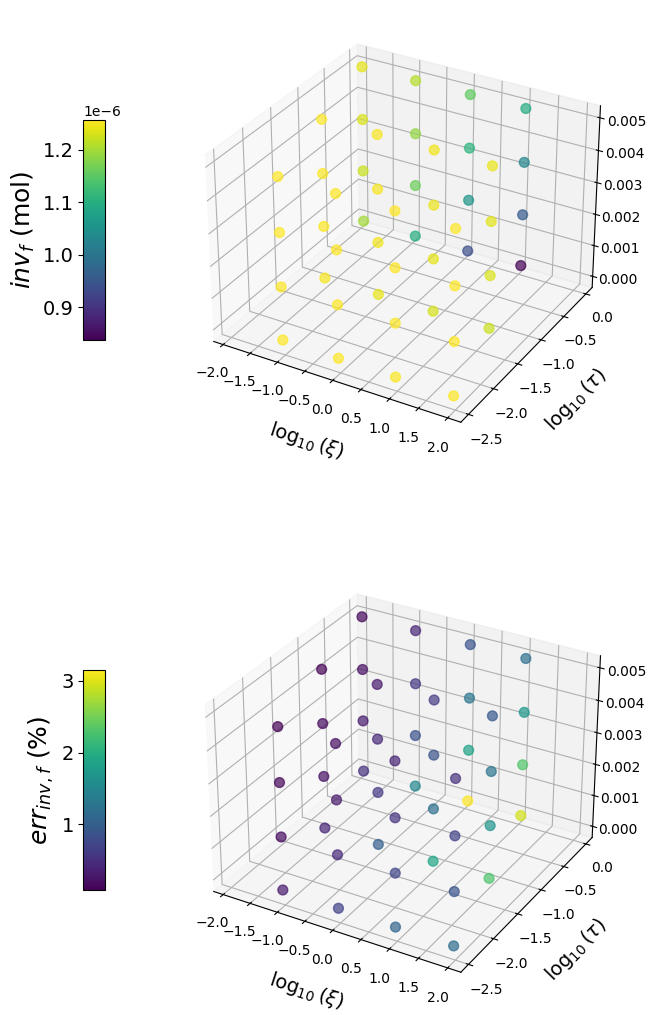

In [6]:
# -------------------------
# Fluid inventory (inv_f, err_inv_f)
# -------------------------
norm1 = plt.Normalize(vmin=abs(plot_data[:, 5]).min(), vmax=abs(plot_data[:, 5]).max())
norm2 = plt.Normalize(vmin=abs(plot_data[:, 6]).min(), vmax=abs(plot_data[:, 6]).max())
colors1 = np.array([
    (1, 0, 0, 1) if value > 5 else cmap(norm1(value))
    for value in abs(plot_data[:, 5])
])
colors2 = np.array([cmap(norm2(value)) for value in abs(plot_data[:, 6])])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), subplot_kw={"projection": "3d"})

sc1 = ax1.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors1, s=50, alpha=0.7)
cbar1 = fig.colorbar(cm.ScalarMappable(norm=norm1, cmap=cmap), ax=ax1, shrink=0.5, aspect=10, location="left")
cbar1.set_label(r'$inv_f$ (mol)', fontsize=18)
cbar1.ax.tick_params(labelsize=14)
_label_axes(ax1)

sc2 = ax2.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors2, s=50, alpha=0.7)
cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm2, cmap=cmap), ax=ax2, shrink=0.5, aspect=10, location="left")
cbar2.set_label(r'$err_{inv,f}$ (%)', fontsize=18)
cbar2.ax.tick_params(labelsize=14)
_label_axes(ax2)

# NOTE: bbox_inches='tight' clips mplot3d z-labels (matplotlib cannot compute a
# correct tight bbox for 3D axis labels), so reserve margin manually instead.
fig.subplots_adjust(left=0.05, right=0.80, bottom=0.05, top=0.95, hspace=0.25)
plt.savefig(os.path.join(RESULTS_DIR, 'MS_PAV_screening_fluid_inventory.png'), dpi=300)
plt.show()

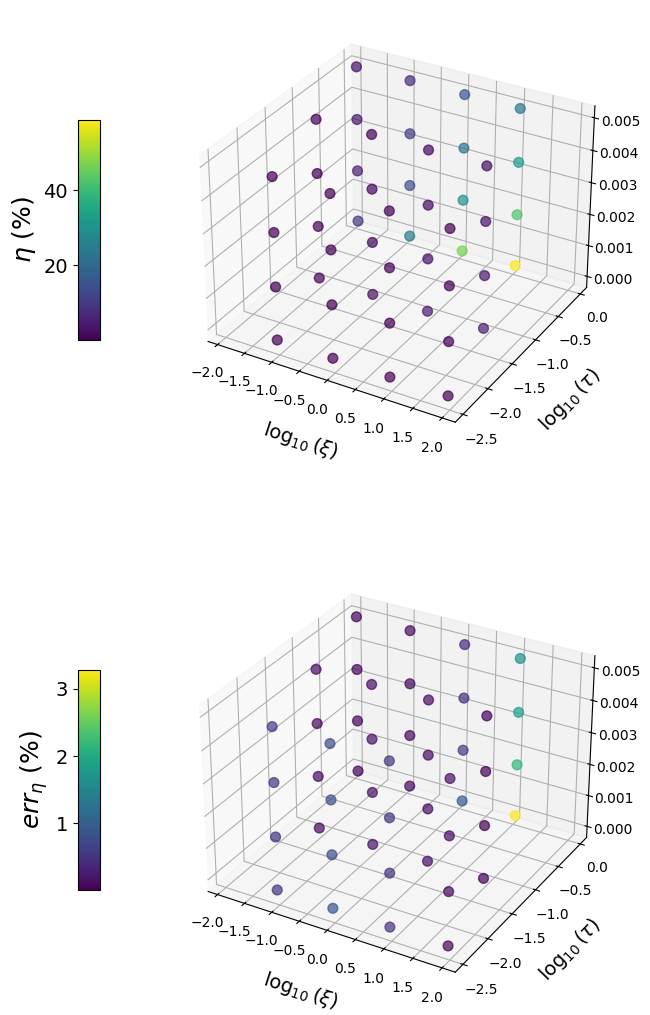

In [7]:
# -------------------------
# Efficiency (eff, err_eff)
# -------------------------
norm1 = plt.Normalize(vmin=abs(plot_data[:, 7]).min(), vmax=abs(plot_data[:, 7]).max())
norm2 = plt.Normalize(vmin=abs(plot_data[:, 8]).min(), vmax=abs(plot_data[:, 8]).max())
colors1 = np.array([cmap(norm1(value)) for value in abs(plot_data[:, 7])])
colors2 = np.array([cmap(norm2(value)) for value in abs(plot_data[:, 8])])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), subplot_kw={"projection": "3d"})

sc1 = ax1.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors1, s=50, alpha=0.7)
cbar1 = fig.colorbar(cm.ScalarMappable(norm=norm1, cmap=cmap), ax=ax1, shrink=0.5, aspect=10, location="left")
cbar1.set_label(r'$\eta$ (%)', fontsize=18)
cbar1.ax.tick_params(labelsize=14)
_label_axes(ax1)

sc2 = ax2.scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], c=colors2, s=50, alpha=0.7)
cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm2, cmap=cmap), ax=ax2, shrink=0.5, aspect=10, location="left")
cbar2.set_label(r'$err_{\eta}$ (%)', fontsize=18)
cbar2.ax.tick_params(labelsize=14)
_label_axes(ax2)

# NOTE: bbox_inches='tight' clips mplot3d z-labels (matplotlib cannot compute a
# correct tight bbox for 3D axis labels), so reserve margin manually instead.
fig.subplots_adjust(left=0.05, right=0.80, bottom=0.05, top=0.95, hspace=0.25)
plt.savefig(os.path.join(RESULTS_DIR, 'MS_PAV_screening_efficiency.png'), dpi=300)
plt.show()